# 05 · Replication: our reproduction vs the paper

Does our pipeline reproduce the numbers the paper (BoltzFT) reports for target 588689? Both are on the same common evaluation set (n = 49,685). This is a replication check, not a cross-method correlation.

What we can compare now: our LightGBM-ECFP baseline vs their reported LightGBM-ECFP, and our Boltz-2 No-FT proxy vs their No-FT. Our own Boltz-2 No-FT and head-FT (from pipeline scoring) are reserved until that scoring finishes.

In [1]:

from pathlib import Path
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display
BLK="#000000"; OUR="#2a78d6"; THEIR="#eb6834"
mpl.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
  "text.color":BLK,"axes.labelcolor":BLK,"axes.titlecolor":BLK,"xtick.color":BLK,"ytick.color":BLK,
  "axes.edgecolor":BLK,"font.size":10,"font.weight":"normal","axes.titleweight":"normal","axes.labelweight":"normal",
  "axes.grid":True,"grid.color":"#e6e6e6","axes.axisbelow":True,"axes.spines.top":False,"axes.spines.right":False})
ROOT=Path("/global/scratch/users/sergiomar10/boltzaff"); D=ROOT/"BoltzFT/figures/data"; T="588689"
# THEIRS (reported by the paper's released CSVs)
sb=pd.read_csv(D/"baseline_cv/supervised_baselines.csv"); sb["target"]=sb.target.astype(str)
their_lgbm=sb[(sb.target==T)&(sb.arm=="ecfp_lgbm_cv")].set_index("train_size")[["ef_1pct","auprc","bedroc"]].sort_index()
tc=pd.read_csv(D/"trainer_control.csv"); tc["target"]=tc.target.astype(str)
their_boltz=tc[tc.target==T].set_index(["arm","n_train"])[["ef_1pct","auprc","bedroc"]]   # base + lightning
# OURS (our reproduction, same eval>300)
o=pd.read_csv(ROOT/"results/analysis/cpu_baselines_588689.csv")
our_lgbm=o[o.method=="LightGBM_ECFP_avg5"].set_index("n_train")[["ef_1pct","auprc","bedroc"]].sort_index()
our_boltz_proxy=o[o.method=="Boltz2_noFT(score)"][["ef_1pct","auprc","bedroc"]].iloc[0]
print("loaded their + our numbers for", T)


loaded their + our numbers for 588689


## LightGBM-ECFP: our reproduction vs the paper's reported value
Same descriptor baseline (2048-bit ECFP), same eval set, budgets N = 40 / 100 / 300.

In [2]:
tab=pd.DataFrame({
  ("EF@1%","paper"):their_lgbm.ef_1pct, ("EF@1%","ours"):our_lgbm.ef_1pct,
  ("AP","paper"):their_lgbm.auprc,       ("AP","ours"):our_lgbm.auprc,
  ("BEDROC","paper"):their_lgbm.bedroc,  ("BEDROC","ours"):our_lgbm.bedroc,
}).round(4); tab.index.name="N (labels)"; display(tab)

EF@1%               AP          BEDROC        
              paper     ours   paper    ours   paper    ours
N (labels)                                                  
40           1.2622   3.5343  0.0149  0.0140  0.1080  0.1195
100          6.3112   7.8259  0.0288  0.0361  0.1914  0.2333
300         10.3504  11.6127  0.0430  0.0427  0.2463  0.2593

## Replication scatter — points on the diagonal = we reproduced their number
x-axis: value reported by the paper; y-axis: our reproduction. One point per label budget. The dashed line is perfect replication (y = x).

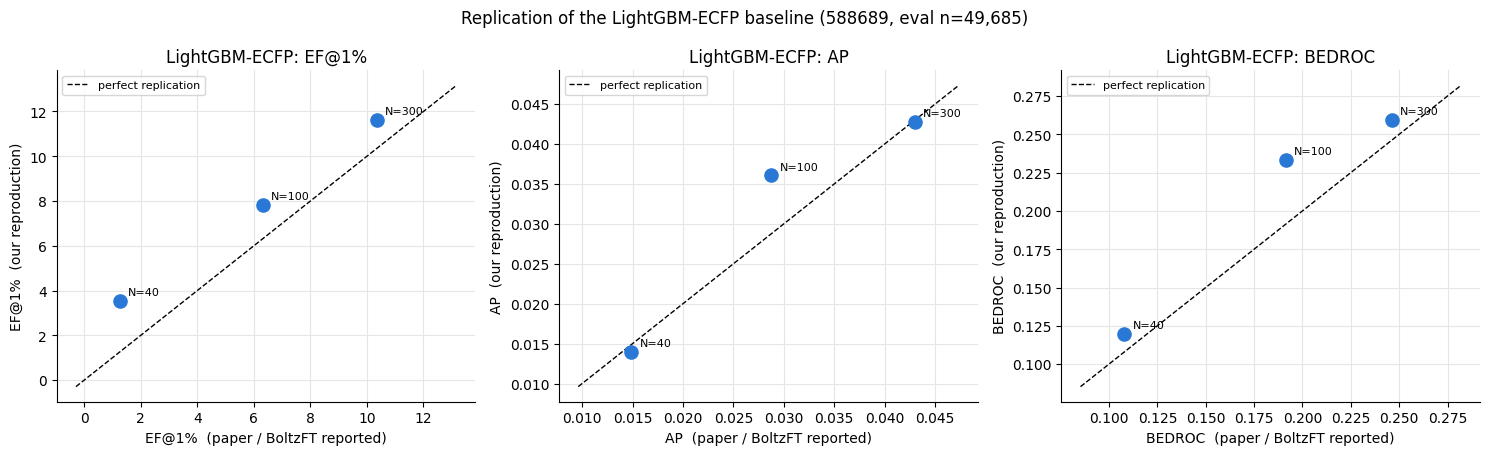

In [3]:
fig,axes=plt.subplots(1,3,figsize=(15,4.6))
for ax,metric,col in zip(axes,["EF@1%","AP","BEDROC"],["ef_1pct","auprc","bedroc"]):
    tx=their_lgbm[col].values; oy=our_lgbm[col].reindex(their_lgbm.index).values
    lo=min(tx.min(),oy.min()); hi=max(tx.max(),oy.max()); pad=(hi-lo)*0.15+1e-6
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],ls="--",color=BLK,lw=1,label="perfect replication")
    ax.scatter(tx,oy,s=90,color=OUR,zorder=3)
    for n,x,y in zip(their_lgbm.index,tx,oy): ax.annotate(f"N={n}",(x,y),textcoords="offset points",xytext=(6,4),fontsize=8)
    ax.set_xlabel(f"{metric}  (paper / BoltzFT reported)"); ax.set_ylabel(f"{metric}  (our reproduction)")
    ax.set_title(f"LightGBM-ECFP: {metric}"); ax.legend(fontsize=8)
fig.suptitle("Replication of the LightGBM-ECFP baseline (588689, eval n=49,685)",fontsize=12)
plt.tight_layout(); plt.show()

## Boltz-2 No-FT: our proxy vs their reported No-FT
Their No-FT (`base`) vs our current proxy, the shipped `score_boltz2`. These are close because both trace to the same standard Boltz-2 inference. Our own pipeline No-FT (from the poses we folded) is reserved below.

In [4]:
base=their_boltz.loc[("base",0)]
cmp=pd.DataFrame({"paper No-FT (base)":[base.ef_1pct,base.auprc,base.bedroc],
                  "our proxy (score_boltz2)":[our_boltz_proxy.ef_1pct,our_boltz_proxy.auprc,our_boltz_proxy.bedroc]},
                 index=["EF@1%","AP","BEDROC"]).round(4); display(cmp)

,paper No-FT (base),our proxy (score_boltz2)
EF@1%,18.1763,18.4288
AP,0.0960,0.0951
BEDROC,0.4550,0.4572


## Why our own Boltz-2 No-FT will not be identical to `score_boltz2`
The shipped `score_boltz2` comes from standard Boltz-2 inference, which reselects a pose during the affinity stage. Our No-FT scores the affinity head on the stored pre-affinity pose (the paper's own protocol, which it distinguishes from the initial ranking). Same model, different pose -> the scores differ. That difference is the paper's `base` arm, which we will reproduce directly once scoring finishes.

## Reserved: head-FT (the headline)
Their reported head-FT (`lightning`) per budget is shown; the `ours` column fills when our 15 FT arms finish scoring. That is the actual replication of the paper's main result.

In [5]:
rows=[]
for n in (40,100,300):
    if ("lightning",n) in their_boltz.index:
        r=their_boltz.loc[("lightning",n)]
        rows.append(dict(N=n, EF_1pct_paper=round(r.ef_1pct,3), AP_paper=round(r.auprc,3),
                         BEDROC_paper=round(r.bedroc,3), EF_1pct_ours="pending", AP_ours="pending"))
display(pd.DataFrame(rows))
print("head-FT (ours) fills in from results/analysis/588689/ once the FT arms score.")

,N,EF_1pct_paper,AP_paper,BEDROC_paper,EF_1pct_ours,AP_ours
0,40,27.012,0.165,0.559,pending,pending
1,100,30.799,0.202,0.606,pending,pending
2,300,31.809,0.237,0.586,pending,pending


head-FT (ours) fills in from results/analysis/588689/ once the FT arms score.
